# 1,3 litros de agua. Sacados del aire. Con sol.

Sin tubería, sin pozo, sin red eléctrica. Un equipo armó una maleta que sacó **1,3 litros de agua potable del aire de Austin** en un día — y siguió funcionando en pleno desierto de Chihuahua, donde hay menos de la mitad de humedad.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Guan et al. (2026), *Nature Water* — [DOI: 10.1038/s44221-026-00645-6](https://doi.org/10.1038/s44221-026-00645-6)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-09-cosecha-agua-atmosferica-solar/notebook.ipynb)

**Video:** _Pendiente_


## ¿De dónde sale el agua?

El aire siempre tiene algo de vapor de agua — incluso en el desierto. El problema de siempre: para condensarlo necesitas enfriar mucho aire, y eso pide energía y equipos pesados. Los aparatos que funcionaban bien no eran portátiles; los portátiles no producían suficiente.

El equipo armó una tela-gel que atrapa vapor de noche y lo suelta de día cuando el sol la calienta. El vapor liberado se condensa en una placa fría, y ahí cae el agua. Lo probaron en dos sitios opuestos: Austin húmedo y el desierto de Chihuahua. Veamos qué cosecharon hora por hora.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
NUBLADO_ML = 310        # agua por módulo en día nublado (~0,4 sol)
COLOR_AUSTIN = '#2563EB'      # azul CaM — sitio húmedo
COLOR_DESIERTO = '#D97706'    # ámbar — desierto
COLOR_ALERTA = '#DC2626'      # rojo — referencia/umbral
COLOR_SECUNDARIO = '#059669'  # emerald
COLOR_VIOLETA = '#7C3AED'
COLOR_GRIS = '#BBBBBB'
FUENTE = 'Fuente: Guan et al. (2026), Nature Water | Datos: Source Data (mismo DOI)'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local → /tmp inyectado → GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de los tres datasets (Source Data del paper)
agua = pd.read_csv('datos/agua_acumulada.csv')
temp = pd.read_csv('datos/temperatura_capas_austin.csv')
sol = pd.read_csv('datos/rendimiento_solar.csv')

austin = agua[agua['sitio'] == 'Austin']
desierto = agua[agua['sitio'] == 'Chihuahuan']

print('Agua acumulada — Austin:', austin['agua_acumulada_ml'].max(), 'mL')
print('Agua acumulada — Chihuahuan:', desierto['agua_acumulada_ml'].max(), 'mL')
print('Días de rendimiento solar:', len(sol), '| módulos single:', (sol['tipo_modulo'] == 'single').sum())
print('Perfil térmico Austin:', len(temp), 'minutos | exterior máx:', temp['exterior_c'].max(), '°C')


Agua acumulada — Austin: 1298.0 mL
Agua acumulada — Chihuahuan: 610.0 mL
Días de rendimiento solar: 11 | módulos single: 10
Perfil térmico Austin: 657 minutos | exterior máx: 100.0 °C


Aquí está.


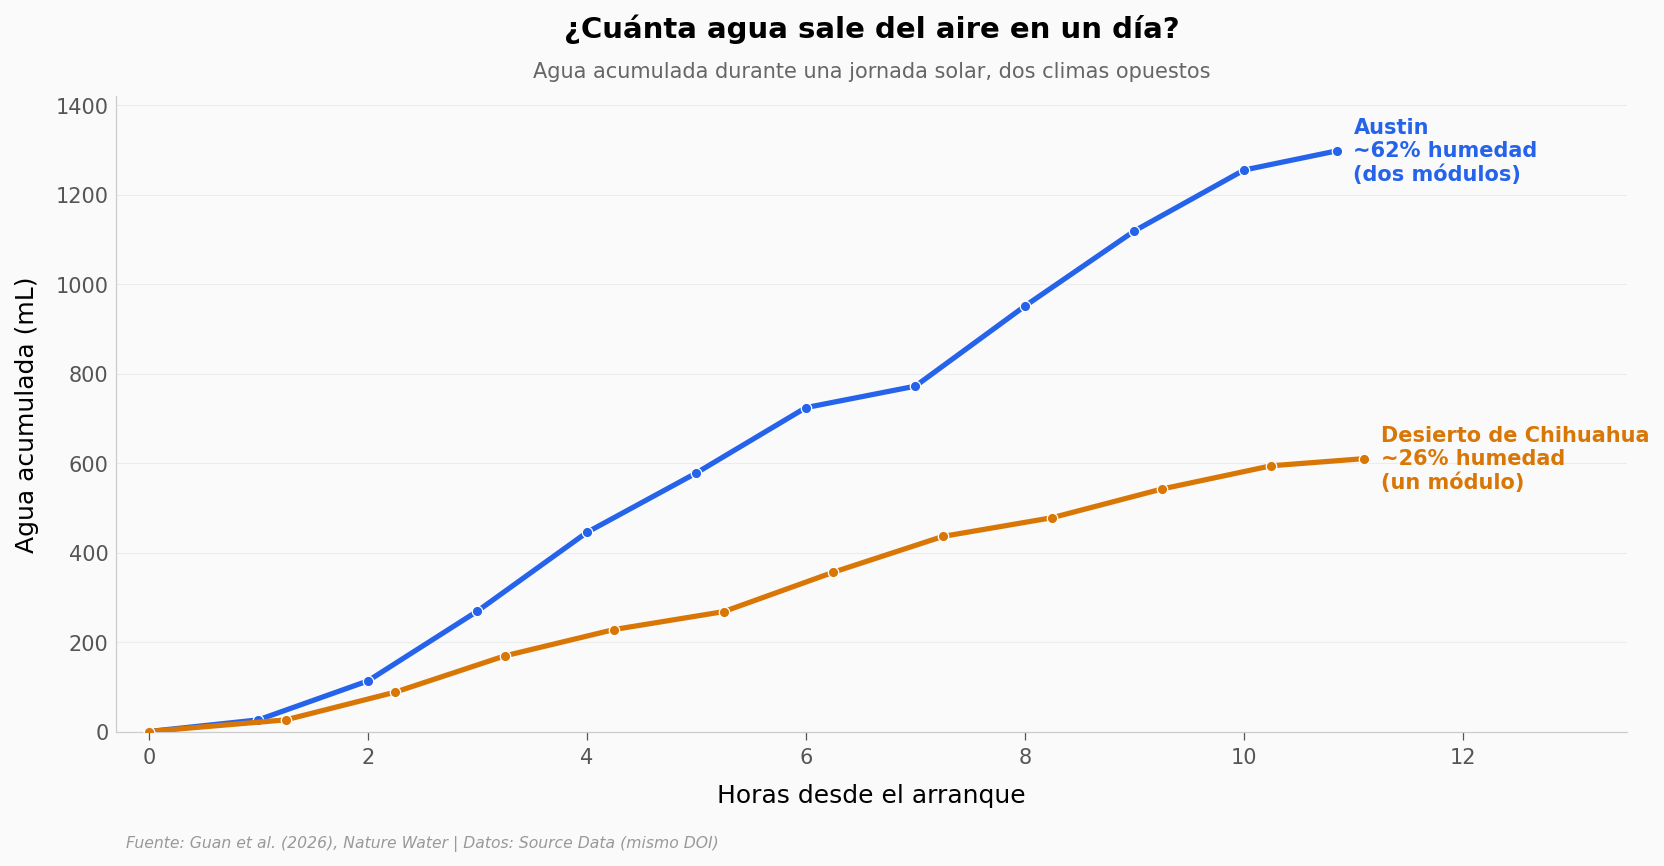

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

ax.plot(austin['horas_desde_inicio'], austin['agua_acumulada_ml'],
        color=COLOR_AUSTIN, linewidth=2.5, marker='o', markersize=5,
        markeredgecolor='white', markeredgewidth=0.6, zorder=5)
ax.plot(desierto['horas_desde_inicio'], desierto['agua_acumulada_ml'],
        color=COLOR_DESIERTO, linewidth=2.5, marker='o', markersize=5,
        markeredgecolor='white', markeredgewidth=0.6, zorder=5)

# Inline labels (reemplazan legend box)
ax.text(austin['horas_desde_inicio'].iloc[-1] + 0.15, 1298,
        'Austin\n~62% humedad\n(dos módulos)', fontsize=10, color=COLOR_AUSTIN,
        fontweight='bold', va='center')
ax.text(desierto['horas_desde_inicio'].iloc[-1] + 0.15, 610,
        'Desierto de Chihuahua\n~26% humedad\n(un módulo)', fontsize=10,
        color=COLOR_DESIERTO, fontweight='bold', va='center')

ax.set_title('¿Cuánta agua sale del aire en un día?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Agua acumulada durante una jornada solar, dos climas opuestos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Horas desde el arranque')
ax.set_ylabel('Agua acumulada (mL)')
ax.set_xlim(-0.3, 13.5)
ax.set_ylim(0, 1420)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/agua_acumulada.png', dpi=200, bbox_inches='tight')
plt.show()


Las dos curvas suben casi toda la jornada — el aparato no da un golpe y para, gotea agua hora tras hora mientras hay sol. Austin termina en 1.298 mL y el desierto en 610 mL, pero esa comparación engaña: Austin usó **dos** módulos y el desierto **uno**.

La comparación justa es la tasa por área de tela: **4,7 L/m²/día en Austin contra 4,3 en el desierto**. La humedad se desplomó de 62% a 26% — menos de la mitad — y la cosecha por metro apenas bajó un 9%. Eso es lo interesante: el aparato casi no se inmuta con el clima.


## ¿Qué empuja el agua hacia afuera?

De noche la tela atrapa vapor; de día el sol concentrado la cocina y el vapor liberado se condensa en una placa que se mantiene fría. ¿Cuánta diferencia de temperatura hace falta para mover el agua? Miremos el termómetro minuto a minuto en Austin.


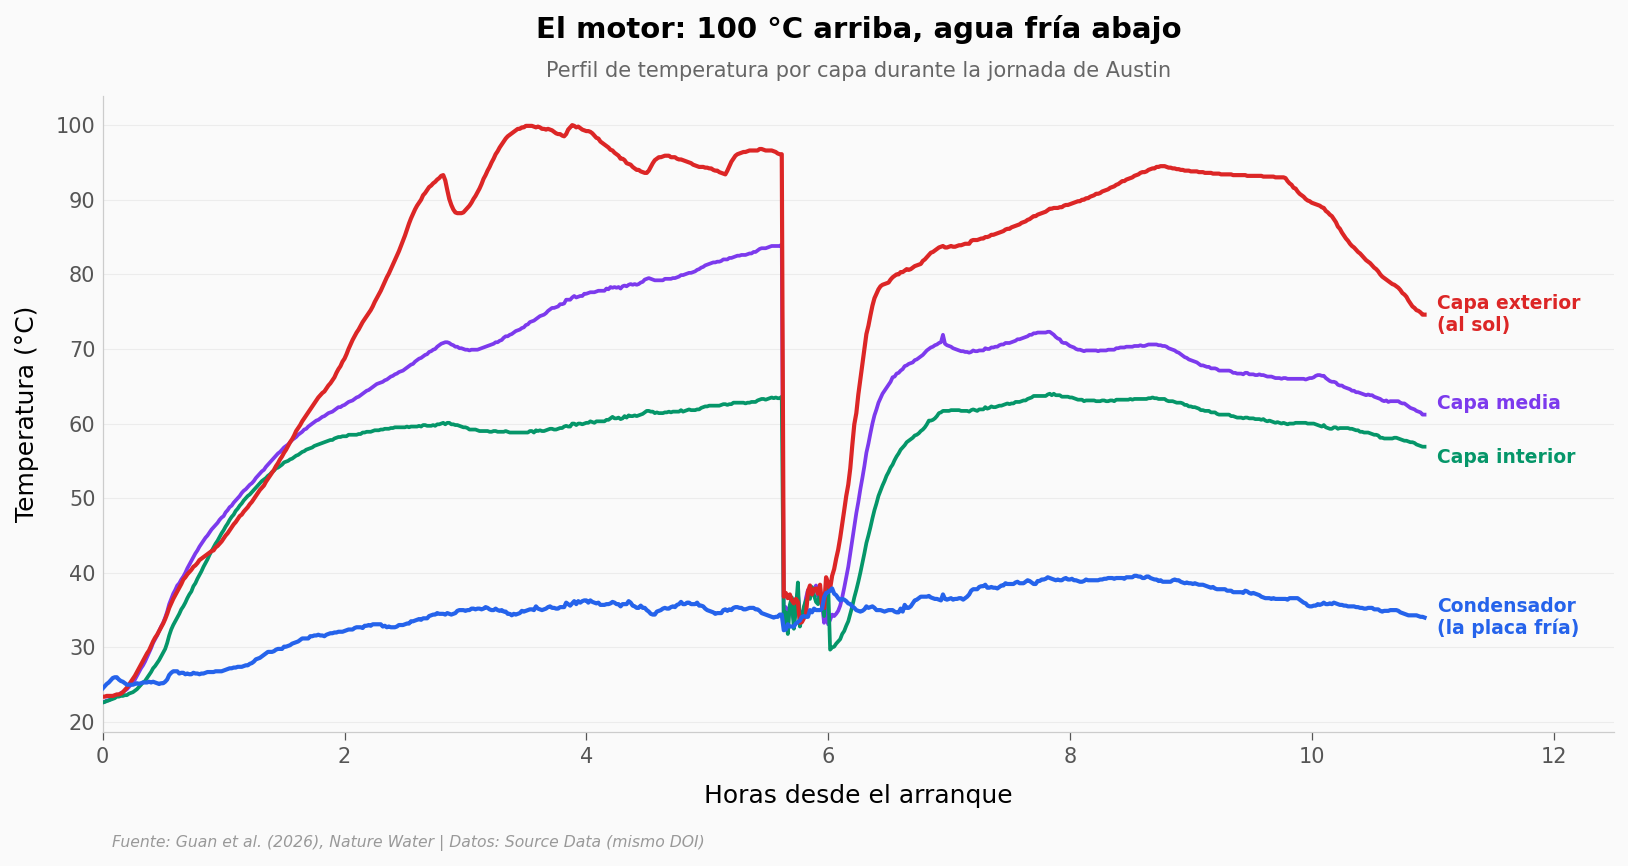

Exterior máximo: 100 °C
Condensador: se mantiene entre 24.5 y 39.6 °C
Gradiente exterior-interior al mediodía: 39 °C


In [3]:
temp['t_horas'] = np.arange(len(temp)) / 60.0  # 1 fila = 1 minuto

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(temp['t_horas'], temp['exterior_c'], color=COLOR_ALERTA, linewidth=2, zorder=5)
ax.plot(temp['t_horas'], temp['medio_c'], color=COLOR_VIOLETA, linewidth=1.8, zorder=4)
ax.plot(temp['t_horas'], temp['interior_c'], color=COLOR_SECUNDARIO, linewidth=1.8, zorder=4)
ax.plot(temp['t_horas'], temp['condensador_c'], color=COLOR_AUSTIN, linewidth=2, zorder=5)

# Inline labels al final de cada serie
xf = temp['t_horas'].iloc[-1]
ax.text(xf + 0.1, temp['exterior_c'].iloc[-1], 'Capa exterior\n(al sol)',
        fontsize=9, color=COLOR_ALERTA, fontweight='bold', va='center')
ax.text(xf + 0.1, temp['medio_c'].iloc[-1] + 1.5, 'Capa media',
        fontsize=9, color=COLOR_VIOLETA, fontweight='bold', va='center')
ax.text(xf + 0.1, temp['interior_c'].iloc[-1] - 1.5, 'Capa interior',
        fontsize=9, color=COLOR_SECUNDARIO, fontweight='bold', va='center')
ax.text(xf + 0.1, temp['condensador_c'].iloc[-1], 'Condensador\n(la placa fría)',
        fontsize=9, color=COLOR_AUSTIN, fontweight='bold', va='center')

ax.set_title('El motor: 100 °C arriba, agua fría abajo',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Perfil de temperatura por capa durante la jornada de Austin',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Horas desde el arranque')
ax.set_ylabel('Temperatura (°C)')
ax.set_xlim(0, 12.5)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/temperatura_capas.png', dpi=200, bbox_inches='tight')
plt.show()

# Gradiente al mediodía (hora 4 desde arranque a las 08:00 → 12:00)
idx_md = (temp['t_horas'] - 4.0).abs().idxmin()
grad_md = temp.loc[idx_md, 'exterior_c'] - temp.loc[idx_md, 'interior_c']
print(f'Exterior máximo: {temp["exterior_c"].max():.0f} °C')
print(f'Condensador: se mantiene entre {temp["condensador_c"].min():.1f} y {temp["condensador_c"].max():.1f} °C')
print(f'Gradiente exterior-interior al mediodía: {grad_md:.0f} °C')


## ¿Más sol, más agua?

Si el sol es el motor, días más soleados deberían dar más agua. El equipo lo midió día tras día. Pero hay una trampa en los datos: un día se usaron **dos** módulos a la vez, así que ese punto produjo el doble por hardware, no por sol. Lo separamos para no engañarnos. Y como un día nublado mete un valor muy bajo que distorsiona las medias, dejamos que los datos elijan el método de correlación según su forma.


Shapiro x p=0.014 | y p=0.199 → uso Spearman
Módulos single (n=10): r=0.64, p=0.0470


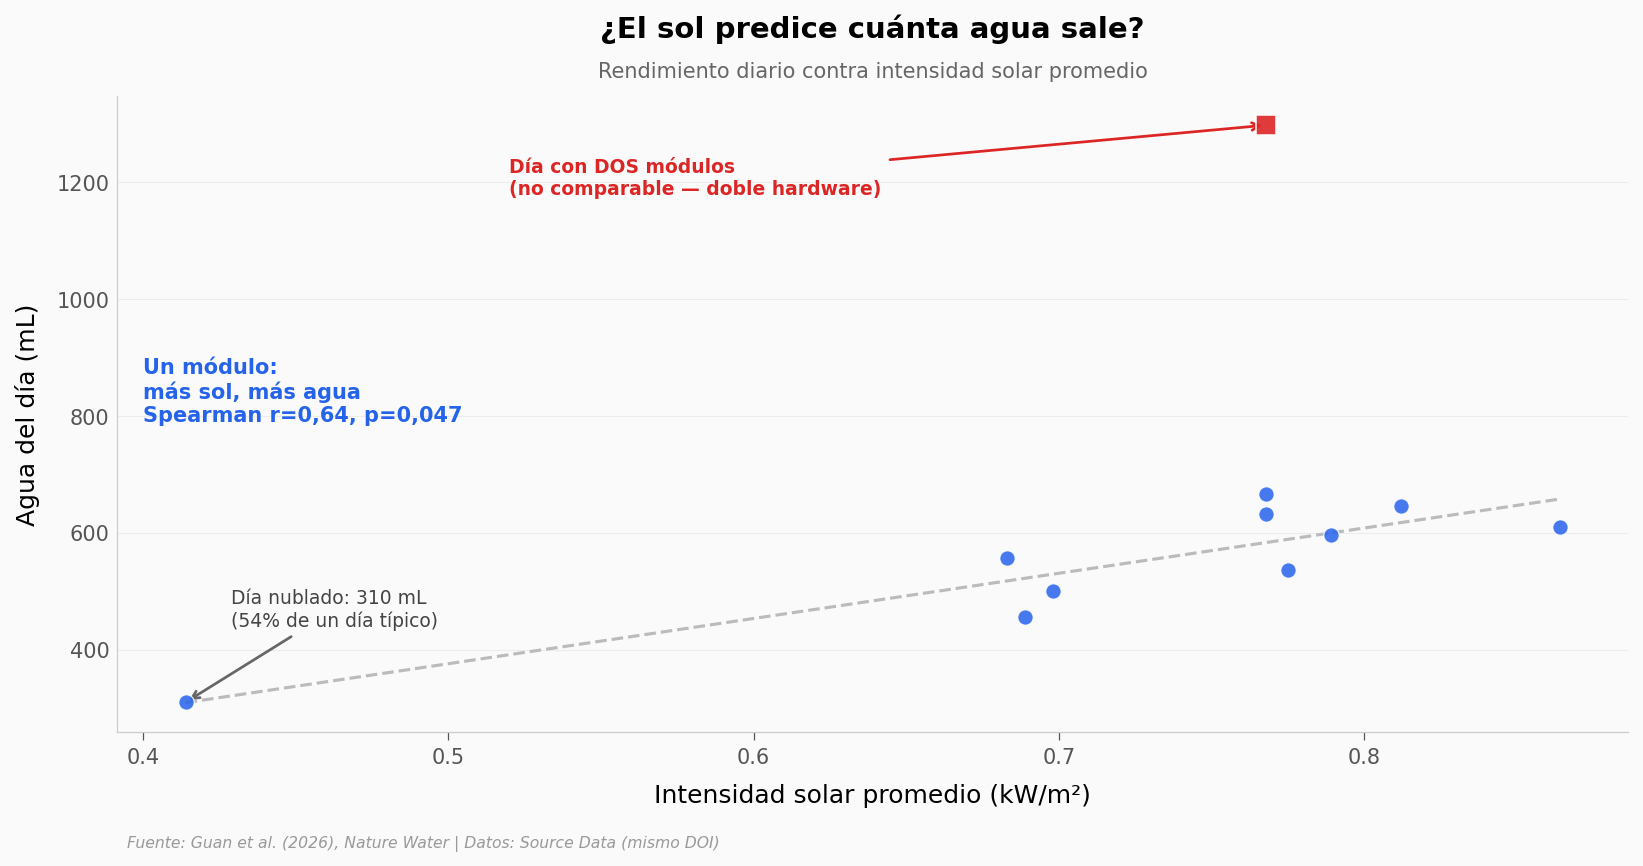

In [4]:
single = sol[sol['tipo_modulo'] == 'single']
dual = sol[sol['tipo_modulo'] == 'dual']

x = single['solar_intensidad_kwm2'].values
y = single['rendimiento_diario_ml'].values

# Normalidad (regla 33): Pearson solo si ambas variables pasan Shapiro
p_sx = stats.shapiro(x).pvalue
p_sy = stats.shapiro(y).pvalue
if p_sx > 0.05 and p_sy > 0.05:
    r, p = stats.pearsonr(x, y)
    metodo = 'Pearson'
else:
    r, p = stats.spearmanr(x, y)
    metodo = 'Spearman'
print(f'Shapiro x p={p_sx:.3f} | y p={p_sy:.3f} → uso {metodo}')
print(f'Módulos single (n={len(x)}): r={r:.2f}, p={p:.4f}')

# Línea de tendencia (ajuste lineal solo para guía visual sobre los single)
slope, intercept = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 50)

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(xs, slope * xs + intercept, color=COLOR_GRIS, linewidth=1.5, linestyle='--', zorder=2)
ax.scatter(x, y, color=COLOR_AUSTIN, s=55, alpha=0.85,
           edgecolors='white', linewidths=0.6, zorder=5)
# Punto dual aparte — el confound
ax.scatter(dual['solar_intensidad_kwm2'], dual['rendimiento_diario_ml'],
           color=COLOR_ALERTA, marker='s', s=90, alpha=0.9,
           edgecolors='white', linewidths=0.8, zorder=6)

# Anotar el día nublado (mínimo de sol) — % vivo respecto a la mediana single
i_nub = x.argmin()
pct_nub = 100 * y[i_nub] / np.median(y)
ax.annotate(f'Día nublado: {y[i_nub]:.0f} mL\n({pct_nub:.0f}% de un día típico)',
            xy=(x[i_nub], y[i_nub]), xytext=(x[i_nub] + 0.015, y[i_nub] + 130),
            fontsize=9, color='#444444',
            arrowprops=dict(arrowstyle='->', color='#666666', lw=1.3))

# Etiqueta del punto dual — apunta al cuadro rojo
ax.annotate('Día con DOS módulos\n(no comparable — doble hardware)',
            xy=(dual['solar_intensidad_kwm2'].iloc[0], dual['rendimiento_diario_ml'].iloc[0]),
            xytext=(0.52, 1180), fontsize=9, color=COLOR_ALERTA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.3))

# Resumen de correlación en zona vacía (arriba-izquierda)
r_txt = f'{r:.2f}'.replace('.', ',')
p_txt = f'{p:.3f}'.replace('.', ',')
ax.text(0.40, 900, f'Un módulo:\nmás sol, más agua\n{metodo} r={r_txt}, p={p_txt}',
        fontsize=10, color=COLOR_AUSTIN, fontweight='bold', va='top')

ax.set_title('¿El sol predice cuánta agua sale?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Rendimiento diario contra intensidad solar promedio',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Intensidad solar promedio (kW/m²)')
ax.set_ylabel('Agua del día (mL)')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/rendimiento_solar.png', dpi=200, bbox_inches='tight')
plt.show()


## ¿Y el peor día?

El sol manda, sí. Pero la pregunta de fondo para un aparato de campo no es cuánto da en su mejor día — es cuánto da en el peor. ¿Qué pasa cuando se nubla?


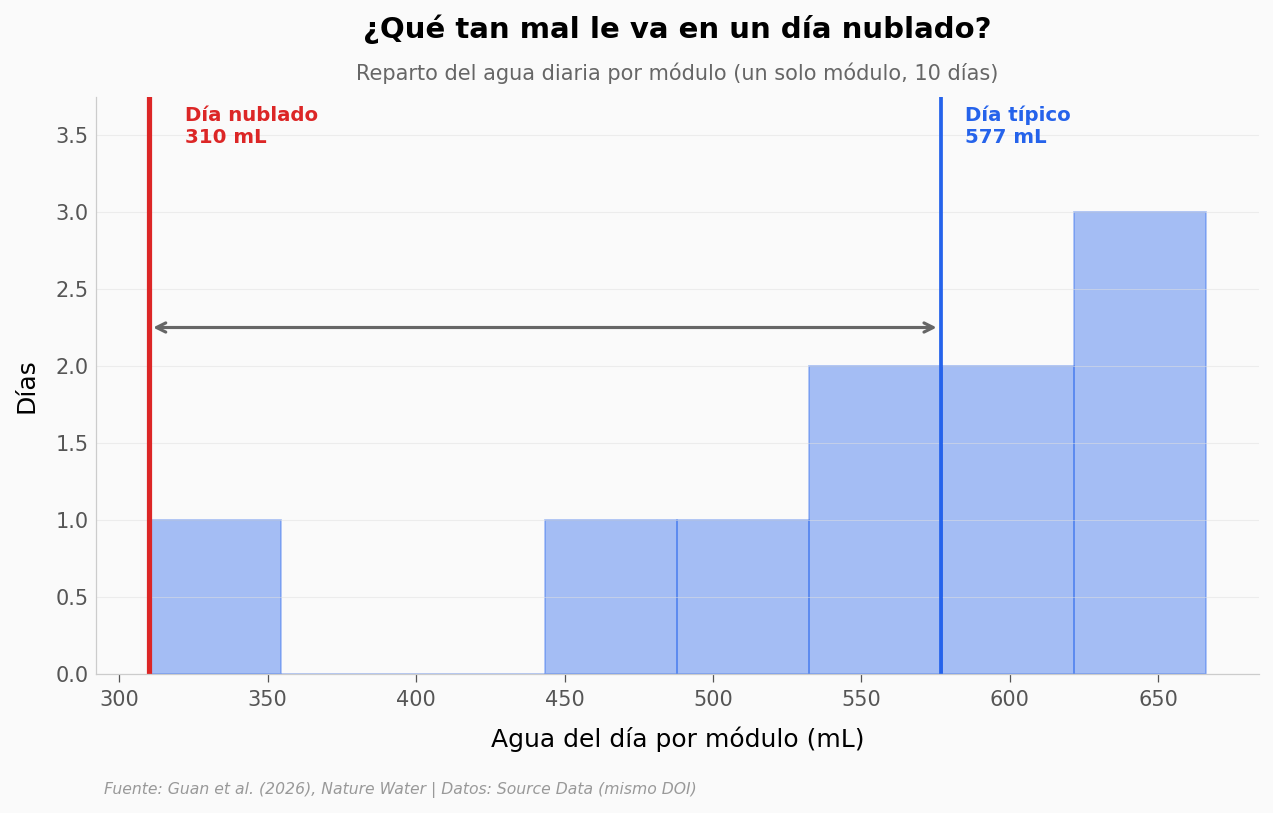

Mediana single: 577 mL | Día nublado: 310 mL (54% de la mediana)


In [5]:
vals = single['rendimiento_diario_ml'].values
mediana = np.median(vals)
nublado = NUBLADO_ML

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, patches = ax.hist(vals, bins=8, color=COLOR_AUSTIN, alpha=0.4,
                           edgecolor=COLOR_AUSTIN, linewidth=0.8)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

ax.axvline(x=mediana, color=COLOR_AUSTIN, linewidth=1.8)
ax.axvline(x=nublado, color=COLOR_ALERTA, linewidth=2.5)
ax.annotate('', xy=(nublado, y_max * 0.6), xytext=(mediana, y_max * 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))

ax.text(mediana + 8, y_max * 0.92, f'Día típico\n{mediana:.0f} mL',
        fontsize=9.5, color=COLOR_AUSTIN, fontweight='bold')
ax.text(nublado + 12, y_max * 0.92, f'Día nublado\n{nublado} mL',
        fontsize=9.5, color=COLOR_ALERTA, fontweight='bold', ha='left')

ax.set_title('¿Qué tan mal le va en un día nublado?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Reparto del agua diaria por módulo (un solo módulo, 10 días)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Agua del día por módulo (mL)')
ax.set_ylabel('Días')

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anomalia_nublado.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Mediana single: {mediana:.0f} mL | Día nublado: {nublado} mL '
      f'({100*nublado/mediana:.0f}% de la mediana)')


### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Austin cosechó ~1,3 L en un día (dual) y el desierto 610 mL (single) | ✅ | Acumulado del Source Data: 1.298 y 610 mL. Coincide con el paper. |
| El aparato es robusto al clima: humedad 62%→26% pero la tasa cae solo ~9% | ✅ | Tasas por área del paper 4,7 vs 4,3 L/m²/día. La comparación justa es por área, no el total (dual vs single). |
| El sol predice el rendimiento de un módulo | ⚠️ | Para módulos single la relación es moderada y apenas significativa (Spearman r≈0,64, p≈0,047, n=10). Usamos Spearman porque la intensidad solar no es normal (Shapiro p=0,01) y un día nublado le da mucho peso. Con el día dual incluido se diluye aún más. n pequeño. |
| Funciona nublado: ~0,4 sol → 310 mL por módulo | ✅ | 54% de un día típico (mediana ~577 mL). El peor día sigue dando agua. |
| El gradiente térmico es el motor | ✅ | Exterior llega a 100 °C, condensador se mantiene 24–40 °C; ~39 °C de diferencia entre la capa exterior y la interior al mediodía. |
| Es una "palanca de equidad" para el ODS 6 | ⚠️ | Es la aspiración de los autores, no un resultado medido. El análisis geoespacial muestra que los picos *coinciden con* zonas de estrés hídrico — asociación, no prueba de impacto. |

> **Limitaciones:** son dos jornadas de campo (un sitio cada una), no un despliegue largo. Las tasas por área dependen del área de tela (~0,14 m²/módulo) y no se recomputan desde estos CSVs. La regresión sol-rendimiento tiene n=10 y un solo día nublado. El total absoluto de Austin no es comparable con el del desierto por usar el doble de módulos.


## Ahora tú

Los datos están aquí. Tres preguntas para explorar:

1. **¿A qué hora produce más?** Calcula `agua_hora_ml` máximo de cada sitio y compáralo. Pista: `agua.groupby('sitio')['agua_hora_ml'].max()`.
2. **¿Cuánto pesa el día dual en la correlación?** Vuelve a correr la regresión incluyendo el punto dual y mira cómo cambian `r` y `p`. Pista: usa `sol` completo en vez de `single`.
3. **¿Cuándo es mayor la diferencia de temperatura?** Encuentra el minuto donde `exterior_c - condensador_c` es máximo. Pista: `(temp['exterior_c'] - temp['condensador_c']).idxmax()`.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿a qué hora pica cada sitio?
pico = agua.loc[agua.groupby('sitio')['agua_hora_ml'].idxmax(), ['sitio', 'hora_local', 'agua_hora_ml']]
print('Pico horario por sitio:')
print(pico.to_string(index=False))

# Pregunta 3: minuto de máxima diferencia exterior-condensador
temp['delta'] = temp['exterior_c'] - temp['condensador_c']
i = temp['delta'].idxmax()
print(f"\nMáxima diferencia exterior-condensador: {temp.loc[i,'delta']:.1f} °C "
      f"a las {temp.loc[i,'hora_local']}")


Pico horario por sitio:
     sitio hora_local  agua_hora_ml
    Austin   12:00:00         176.0
Chihuahuan   14:00:00          88.0

Máxima diferencia exterior-condensador: 65.0 °C a las 11:26:00


## Reproducir

Todo el análisis corre con `pandas`, `numpy`, `matplotlib` y `scipy`. Los CSVs están en `datos/` y salen del Source Data del paper (mismo DOI).

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-09-cosecha-agua-atmosferica-solar/notebook.ipynb)

## Fuentes

**Paper**: [Field-portable, solar-powered, litre-scale atmospheric water harvesting across climates with gel fabric architecture](https://doi.org/10.1038/s44221-026-00645-6)  
*Nature Water, 2026-06-09*

**Source Data**: [Source Data Figs. 1–4 — Guan et al., Nature Water (s44221-026-00645-6)](https://static-content.springer.com/esm/art%3A10.1038%2Fs44221-026-00645-6/MediaObjects/44221_2026_645_MOESM2_ESM.zip)  
*Datos de las Figs. 1–4 del mismo DOI*

*17 afirmaciones del notebook verificadas contra estas fuentes*
